In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression, Lasso

In [2]:
root_path = "/home/stefan/ioai-prep/kits/gaia/data-reduction"

seed = 42

# Setup

In [3]:
def prep_df(df: pd.DataFrame):
    X = df.drop(["class"], axis=1)
    y= df["class"]

    y = y.map({"neg": 0, "pos": 1})

    return X, y

In [4]:
train_df = pd.read_csv(f"{root_path}/train_data.csv")
X_train, y_train = prep_df(train_df)

test_df = pd.read_csv(f"{root_path}/test_data.csv")
X_test, y_test = prep_df(test_df)

In [5]:
train_df.shape

(2870, 195)

In [6]:
clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=None,
        min_samples_leaf=1,
    )),
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

In [7]:
preds = clf.predict(X_test)
f1_score(y_test, preds)

0.9232804232804233

# Lasso feature selection

In [8]:
lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, C=0.1)),
])

lasso.fit(X_train, y_train)

/home/stefan/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/stefan/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

<BarContainer object of 194 artists>

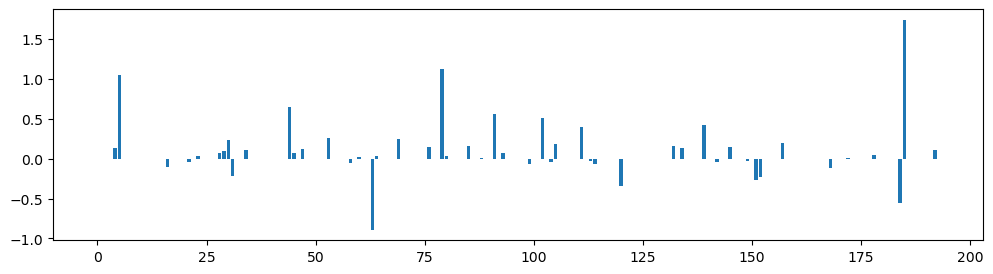

In [9]:
coef = lasso["lasso"].coef_[0]

plt.figure(figsize=(12, 3))
plt.bar([i for i in range(len(coef))], coef)

In [10]:
coef_paired = []

for i in range(len(coef)):
    coef_paired.append((coef[i], i))

coef_paired = sorted(coef_paired, key=lambda x: abs(x[0]), reverse=True)
len(coef_paired)

194

In [68]:
keep_ratio = 0.36 #0.95
cutoff = int(len(coef_paired) * keep_ratio)
good_ids = sorted([pair[1] for pair in coef_paired[:cutoff]])

len(good_ids)

69

In [69]:
p = len(good_ids) / len(coef)
f"{p*100:.2f}%"

'35.57%'

In [70]:
selected_rows = [i for i in range(len(train_df.sample(frac=0.95, random_state=seed)))]
selected_cols = good_ids

# Evaluation

In [71]:
r = X_test.shape[0]
c = X_test.shape[1]

In [72]:
X_train_reduced = X_train.iloc[selected_rows, selected_cols]
y_train_reduced = y_train.iloc[selected_rows]

X_test_reduced = X_test.iloc[:, selected_cols]

In [73]:
clf.fit(X_train_reduced, y_train_reduced)

preds_reduced = clf.predict(X_test_reduced)
score = f1_score(y_test, preds_reduced)

score

0.9090909090909091

In [74]:
def calculate_score(r, r_now, c, c_now):
    """
    Calculates the score based on log ratios of r and c.

    Args:
        r: Initial or reference value for r.
        r_now: Current value for r.
        c: Initial or reference value for c.
        c_now: Current value for c.

    Returns:
        The calculated score as a float.
    """
    term_r = math.log(r / r_now) / math.log(r)
    term_c = math.log(c / c_now) / math.log(c)

    score = 0.5 * term_r + 0.5 * term_c
    return score

In [78]:
# if score >= 0.92:
print(calculate_score(r, X_test_reduced.shape[0], c, len(selected_cols)) * 100)

9.811878217407044


In [ ]:
# %%
import pandas as pd
import numpy as np
import json
import math
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score

# %%
root_path = "/home/stefan/ioai-prep/kits/gaia/data-reduction"
seed = 42


def prep_df(df: pd.DataFrame):
    X = df.drop(["class"], axis=1)
    # Convert all columns to numeric, forcing errors to NaN
    X = X.apply(pd.to_numeric, errors="coerce")
    y = df["class"].map({"neg": 0, "pos": 1})
    return X, y


# %%
# Load Data
train_df = pd.read_csv(f"{root_path}/train_data.csv")
X_train, y_train = prep_df(train_df)

# %%
# 1. Rank Features using Decision Tree Importance
# Use full data to find the most robust features for the DT model
pipe_rank = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(random_state=seed, class_weight="balanced")),
    ]
)
pipe_rank.fit(X_train, y_train)

importances = pipe_rank.named_steps["clf"].feature_importances_
sorted_indices = np.argsort(importances)[::-1]

# %%
# 2. Find minimal columns and rows
# We target a local F1 slightly higher than 0.92 to ensure private set success.
TARGET_F1 = 0.92


def evaluate_subset(cols, rows):
    X_sub = X_train.iloc[rows, cols]
    y_sub = y_train.iloc[rows]

    clf = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(random_state=seed, class_weight="balanced")),
        ]
    )
    clf.fit(X_sub, y_sub)

    # Evaluate on the full training set (as a proxy for the test set)
    preds = clf.predict(X_train.iloc[:, cols])
    return f1_score(y_train, preds)


# Identify indices by class
pos_idx = y_train[y_train == 1].index.tolist()
neg_idx = y_train[y_train == 0].index.tolist()

selected_cols = []
selected_rows = []

# Greedy Column Search
for i in range(1, 150):
    current_cols = sorted_indices[:i].tolist()
    # Greedy Row Search: Keep all positive, add few negative
    for n_neg in [50, 100, 150, 200, 300, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800]:
        current_rows = sorted(pos_idx + neg_idx[:n_neg])
        score = evaluate_subset(current_cols, current_rows)
        if score >= TARGET_F1:
            selected_cols = current_cols
            selected_rows = current_rows
            break
    if selected_cols:
        break

# %%
# 3. Final Verification and Scoring
r_total, c_total = 2870, 194
r_now, c_now = len(selected_rows), len(selected_cols)

f1_final = evaluate_subset(selected_cols, selected_rows)
comp_score = (
    0.5 * (math.log(r_total / r_now) / math.log(r_total))
    + 0.5 * (math.log(c_total / c_now) / math.log(c_total))
) * 100

print(f"Final F1: {f1_final:.4f}")
print(f"Rows: {r_now}, Columns: {c_now}")
print(f"Estimated Score: {comp_score:.2f}")

# %%
# 4. Submission
submission = {
    "rows": [int(r) for r in selected_rows],
    "columns": [int(c) for c in selected_cols],
}

with open("submission.json", "w") as f:
    json.dump(submission, f)

Final F1: 0.9064
Rows: 1648, Columns: 1
Estimated Score: 53.48
